In [3]:
import os
from tqdm import tqdm
import sys
if not hasattr(sys.modules[__name__], "cwd_changed"):
    os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__name__))))
    sys.modules[__name__].cwd_changed = True

import warnings 
warnings.filterwarnings("ignore")
from utils.plotting import GraphVisualization
import pandas as pd
from utils.data import read_data_files

ImportError: cannot import name 'GraphVisualization' from 'utils.plotting' (d:\Thesis\Repository\utils\plotting.py)

In [5]:
import pickle

# subset = 'binaryManyRoots'
subset = 'jpmf_grid'

# with open(f'results/ea_ii/{subset}.pkl', 'rb') as f:
#     results = pickle.load(f)

with open(f'results/ges/{subset}.pkl', 'rb') as f:
    ges_results = pickle.load(f)

with open(f'results/hc/{subset}.pkl', 'rb') as f:
    hc_results = pickle.load(f)

In [9]:
results= ges_results

In [10]:
idx = 5
results_sub = results[idx]
viz = GraphVisualization(metadata=results_sub.metadata[0], results=results_sub.learned_dags[0])
# viz.visualize_network_labels(
# viz.compare_dags_with_labels()
print(results_sub.bic_scores[0])

NameError: name 'GraphVisualization' is not defined

In [7]:
idx = 0
results_sub = ges_results[idx]
viz = GraphVisualization(metadata=results_sub.metadata[0], results=results_sub.learned_dags[0])
# viz.visualize_network_labels(
# viz.compare_dags_with_labels()
print(results_sub.bic_scores[0])

NameError: name 'GraphVisualization' is not defined

In [116]:
idx = 0
results_sub = hc_results[idx]
viz = GraphVisualization(metadata=results_sub.metadata[0], results=results_sub.learned_dags[0])
# viz.visualize_network_labels(
# viz.compare_dags_with_labels()
print(results_sub.bic_scores[0])

-62921.217927912454


In [117]:
from causallearn.utils.DAG2CPDAG import dag2cpdag
import networkx as nx

In [119]:
import networkx as nx
from itertools import combinations

def dag_to_pdag_nx(dag: nx.DiGraph) -> nx.Graph:
    """
    Convert a DAG to a PDAG using v-structure preservation.
    """
    pdag = nx.Graph()
    pdag.add_nodes_from(dag.nodes())

    # Step 1: find v-structures
    v_structures = set()
    for z in dag.nodes():
        parents = list(dag.predecessors(z))
        for x, y in combinations(parents, 2):
            if not dag.has_edge(x, y) and not dag.has_edge(y, x):
                v_structures.add((x, z))
                v_structures.add((y, z))

    # Step 2: add edges
    for u, v in dag.edges():
        if (u, v) in v_structures:
            pdag.add_edge(u, v, directed=True)
        else:
            pdag.add_edge(u, v)

    return pdag


In [134]:
dag = results_sub.learned_dags[0]
# pdag = dag_to_pdag_nx(dag)

In [1]:
from __future__ import annotations
import itertools
import networkx as nx


def dag_to_cpdag(dag: nx.DiGraph) -> tuple[nx.DiGraph, nx.Graph]:
    """
    Convert a DAG (nx.DiGraph) to its CPDAG (essential graph).

    Returns
    -------
    directed : nx.DiGraph
        The directed part of the CPDAG (compelled edges).
    undirected : nx.Graph
        The undirected part of the CPDAG (reversible edges).
    """
    if not nx.is_directed_acyclic_graph(dag):
        raise ValueError("Input must be a DAG (directed and acyclic).")

    nodes = list(dag.nodes())
    directed = nx.DiGraph()
    directed.add_nodes_from(nodes)

    # Start with the skeleton: all DAG adjacencies as undirected edges
    undirected = nx.Graph()
    undirected.add_nodes_from(nodes)
    for u, v in dag.edges():
        undirected.add_edge(u, v)

    # Helper to represent CPDAG as single DiGraph
    def as_single_networkx_digraph(directed: nx.DiGraph, undirected: nx.Graph) -> nx.DiGraph:
        """
        Optional: represent the CPDAG as a single DiGraph by encoding undirected edges
        as two opposite directed edges with attribute `kind="undirected"`.
        """
        g = nx.DiGraph()
        g.add_nodes_from(directed.nodes())
        g.add_edges_from(directed.edges(), kind="directed")
        for u, v in undirected.edges():
            print(f"undirected edge: {u} -- {v}")
            g.add_edge(u, v, kind="undirected")
            g.add_edge(v, u, kind="undirected")
        return g

    def adjacent(a, b) -> bool:
        return (
            undirected.has_edge(a, b)
            or directed.has_edge(a, b)
            or directed.has_edge(b, a)
        )

    def would_create_cycle(u, v) -> bool:
        # adding u->v creates a directed cycle iff v reaches u already
        return nx.has_path(directed, v, u)

    def orient(u, v) -> bool:
        """Orient undirected edge u-v into u->v. Returns True if changed."""
        if not undirected.has_edge(u, v):
            return False
        if directed.has_edge(v, u):
            raise ValueError(f"Conflict: trying to orient {u}->{v} but {v}->{u} already directed.")
        if would_create_cycle(u, v):
            raise ValueError(f"Would create directed cycle by orienting {u}->{v}.")
        undirected.remove_edge(u, v)
        directed.add_edge(u, v)
        return True

    # 1) Orient v-structures: for each node b, for each pair of parents a,c
    for b in nodes:
        parents = list(dag.predecessors(b))
        for a, c in itertools.combinations(parents, 2):
            # "unshielded": a and c not adjacent in skeleton
            if not undirected.has_edge(a, c):
                # collider a -> b <- c is compelled in the CPDAG
                if undirected.has_edge(a, b):
                    orient(a, b)
                if undirected.has_edge(c, b):
                    orient(c, b)

    # 2) Close under Meek rules (R1–R4) until convergence :contentReference[oaicite:1]{index=1}
    changed = True
    while changed:
        changed = False

        # R1: a->b and b-c and a not adjacent c  =>  orient b->c
        for a, b in list(directed.edges()):
            for c in list(undirected.neighbors(b)):
                if not adjacent(a, c):
                    changed |= orient(b, c)

        # Helper: try orienting x-y either direction if a rule fires
        def try_orient_either(x, y, predicate_xy) -> bool:
            # try x->y first
            if predicate_xy(x, y):
                return orient(x, y)
            # else try y->x
            if predicate_xy(y, x):
                return orient(y, x)
            return False

        # Precompute successor sets for faster checks
        succ = {u: set(directed.successors(u)) for u in directed.nodes()}

        # R2: a-b and a->c->b  => orient a->b
        for x, y in list(undirected.edges()):
            def r2(a, b):
                return any((c in succ[a]) and directed.has_edge(c, b) for c in succ[a])
            changed |= try_orient_either(x, y, r2)

        # R3: a-b and (a-k -> b) and (a-l -> b) with k nonadjacent l  => orient a->b
        for x, y in list(undirected.edges()):
            def r3(a, b):
                # candidates k where a-k undirected and k->b directed
                ks = [k for k in undirected.neighbors(a) if directed.has_edge(k, b)]
                if len(ks) < 2:
                    return False
                for k, l in itertools.combinations(ks, 2):
                    if not adjacent(k, l):
                        return True
                return False
            changed |= try_orient_either(x, y, r3)

        # R4: a-b and a-k and k->l->b with k nonadjacent b  => orient a->b
        for x, y in list(undirected.edges()):
            def r4(a, b):
                for k in undirected.neighbors(a):  # a-k (undirected)
                    if adjacent(k, b):
                        continue
                    # chain k->l->b
                    for l in succ.get(k, ()):
                        if directed.has_edge(l, b):
                            return True
                return False
            changed |= try_orient_either(x, y, r4)

    return as_single_networkx_digraph(directed, undirected)


In [2]:
cpdag_nx = dag_to_cpdag(dag)

NameError: name 'dag' is not defined

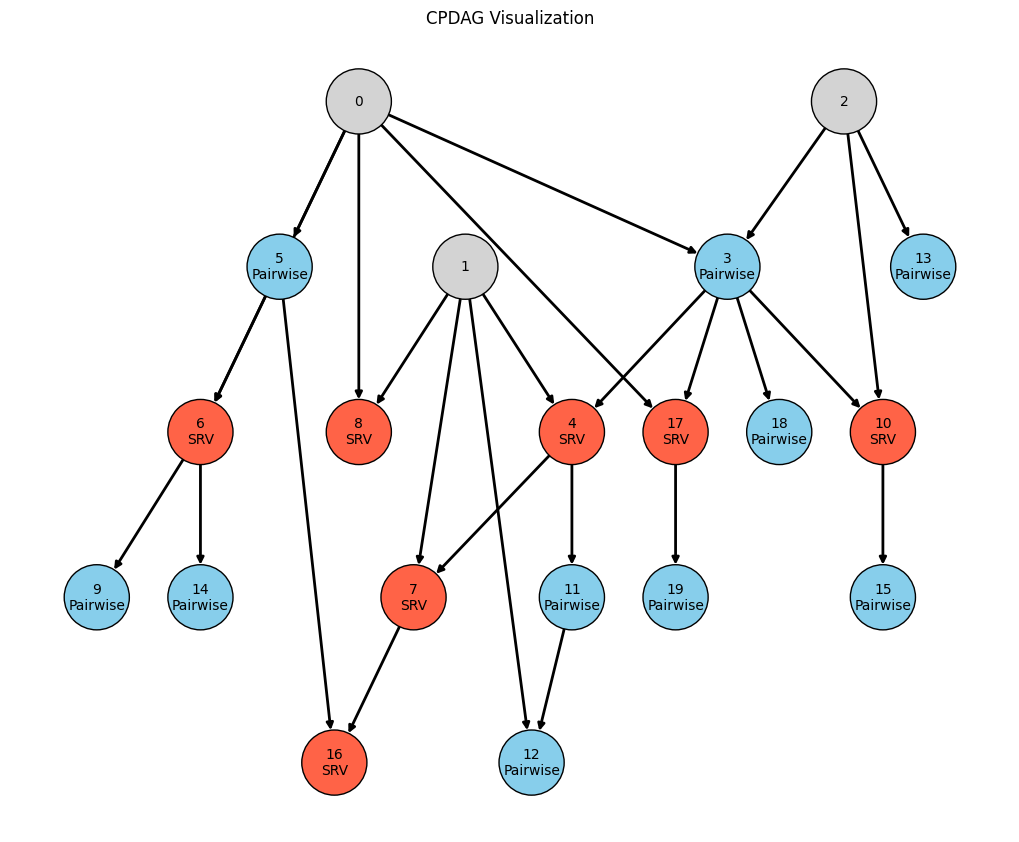

In [184]:
visualize_network_labels(results_sub.metadata[0], title="CPDAG Visualization")

In [185]:
def compare_dags_with_labels(true_graph,
                             learned_graph,
                             metadata=None,
                             title="Learned vs True DAG",
                             logic_map=None):
    """
    Compare learned DAG to true DAG and visualize with detailed node labels.

    Parameters
    ----------
    true_graph : nx.DiGraph
    learned_graph : nx.DiGraph
    metadata : pandas.DataFrame or None
        DataFrame with columns 'Combs' and 'Type' (for SRV/Pairwise kind labels).
    logic_map : dict, optional
        Mapping {node: text} for extra label info.
    title : str
        Plot title.
    """
    import ast
    from collections import defaultdict
    import matplotlib.pyplot as plt
    import networkx as nx

    # --- Build type mapping from DF (optional) ---
    node_kind = defaultdict(set)
    if metadata is not None:
        for _, row in metadata.iterrows():
            comb = row["Combs"]
            if isinstance(comb, str):
                comb = ast.literal_eval(comb)
            kind = row["Type"]
            if len(comb) == 3:
                _, _, w = comb
                node_kind[w].add(kind)
            elif len(comb) == 2:
                _, v = comb
                node_kind[v].add(kind)

    print("True Graph")
    print(list(true_graph.edges()))
    print("Learned Graph")
    print(list(learned_graph.edges()))

    # --- Convert to sets of int tuples ---
    true_set = {(int(u), int(v)) for u, v in true_graph.edges()}
    learned_set = {(int(u), int(v)) for u, v in learned_graph.edges()}

    # --- Reverse edges for direction check ---
    true_rev = {(v, u) for (u, v) in true_set}

    # --- Compare ---
    correct = learned_set & true_set
    wrong_dir = learned_set & true_rev
    extra = learned_set - (true_set | true_rev)
    missing = true_set - (learned_set | true_rev)

    # --- Print comparison results ---
    print("\n✅ Correct edges:", sorted(correct))
    print("🔄 Wrong-direction edges:", sorted(wrong_dir))
    print("⚠️ Extra edges:", sorted(extra))
    print("❌ Missing edges:", sorted(missing))

    # --- Precision / Recall / F1 ---
    tp = len(correct)
    fp = len(extra) + len(wrong_dir)
    fn = len(missing)

    precision = tp / (tp + fp) if tp + fp > 0 else 0.0
    recall = tp / (tp + fn) if tp + fn > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0
    print(f"\n📊 Precision: {precision:.2f}, Recall: {recall:.2f}, F1: {f1:.2f}")

    # --- Edge colors for learned DAG visualization ---
    edge_list = []
    edge_colors = []
    for u, v in learned_set:
        edge_list.append((u, v))
        if (u, v) in correct:
            edge_colors.append("green")
        elif (u, v) in wrong_dir:
            edge_colors.append("yellow")
        else:
            edge_colors.append("red")

    # --- Layout (use true_graph for consistent positions) ---
    try:
        from networkx.drawing.nx_agraph import graphviz_layout
        pos = graphviz_layout(true_graph, prog="dot")
    except Exception:
        pos = nx.spring_layout(true_graph, seed=42)

    # --- Labels and Node Colors ---
    node_labels = {}
    node_colors = []
    for n in true_graph.nodes():
        lines = [str(n)]
        if logic_map and n in logic_map:
            lines.append(str(logic_map[n]))
        if node_kind and n in node_kind:
            lines.append("/".join(sorted(node_kind[n])))
        node_labels[n] = "\n".join(lines)

        kinds = node_kind.get(n, set())
        if "SRV" in kinds and "Pairwise" in kinds:
            node_colors.append("violet")
        elif "SRV" in kinds:
            node_colors.append("tomato")
        elif "Pairwise" in kinds:
            node_colors.append("skyblue")
        else:
            node_colors.append("lightgrey")

    # --- Draw ---
    plt.figure(figsize=(12, 10))

    # True DAG as background
    nx.draw(true_graph, pos,
            node_color=node_colors,
            labels=node_labels,
            node_size=2500,
            edgecolors="black",
            arrows=False,
            width=2,
            font_size=9)

    # Learned DAG overlay: edges only
    nx.draw_networkx_edges(learned_graph, pos,
                           edgelist=edge_list,
                           edge_color=edge_colors,
                           arrows=True,
                           width=2)

    plt.title(title)
    plt.tight_layout()
    plt.show()

    # optional: return the sets/metrics for programmatic use
    return {
        "correct": correct,
        "wrong_dir": wrong_dir,
        "extra": extra,
        "missing": missing,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


True Graph
[(0, 3), (0, 5), (0, 6), (0, 8), (0, 17), (3, 4), (3, 10), (3, 17), (3, 18), (2, 3), (2, 10), (2, 13), (1, 4), (1, 7), (1, 8), (1, 12), (4, 7), (4, 11), (5, 6), (5, 16), (6, 9), (6, 14), (7, 16), (10, 15), (11, 12), (17, 19)]
Learned Graph
[('0', '8'), ('0', '19'), ('0', '17'), ('0', '2'), ('19', '17'), ('17', '2'), ('2', '10'), ('2', '13'), ('1', '8'), ('1', '4'), ('1', '3'), ('1', '12'), ('1', '7'), ('4', '8'), ('4', '1'), ('4', '11'), ('4', '3'), ('4', '12'), ('4', '7'), ('3', '19'), ('3', '17'), ('3', '10'), ('3', '5'), ('3', '1'), ('3', '4'), ('3', '18'), ('3', '7'), ('12', '1'), ('12', '4'), ('12', '11'), ('10', '15'), ('18', '3'), ('5', '16'), ('5', '0'), ('11', '4'), ('11', '12'), ('6', '5'), ('6', '0'), ('6', '9'), ('6', '14'), ('9', '6'), ('7', '16'), ('7', '1'), ('7', '4'), ('7', '3'), ('14', '6')]

✅ Correct edges: [(0, 8), (0, 17), (1, 4), (1, 7), (1, 8), (1, 12), (2, 10), (2, 13), (3, 4), (3, 10), (3, 17), (3, 18), (4, 7), (4, 11), (5, 16), (6, 9), (6, 14), (7,

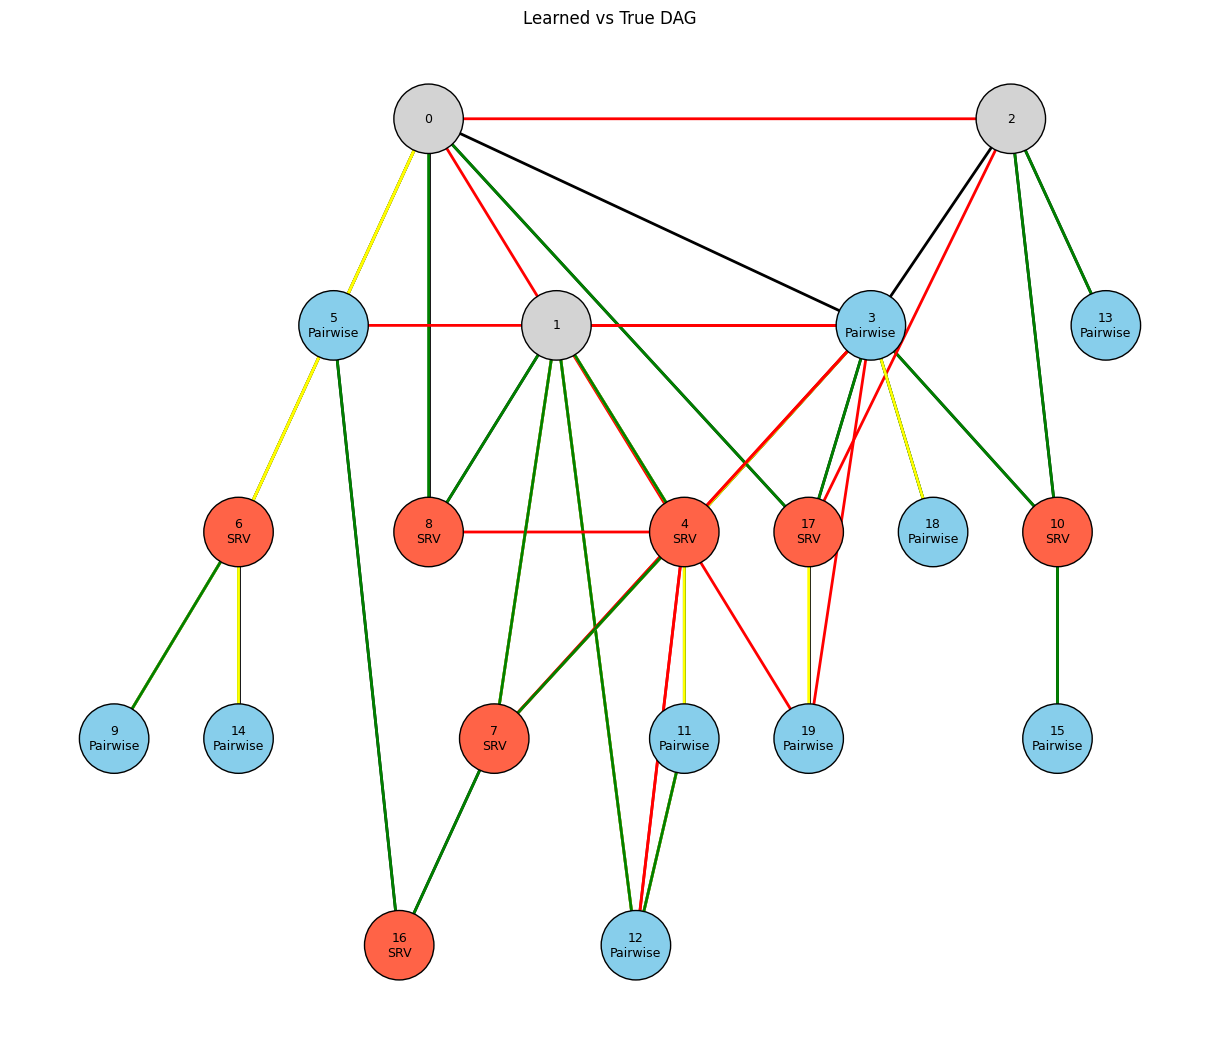

{'correct': {(0, 8),
  (0, 17),
  (1, 4),
  (1, 7),
  (1, 8),
  (1, 12),
  (2, 10),
  (2, 13),
  (3, 4),
  (3, 10),
  (3, 17),
  (3, 18),
  (4, 7),
  (4, 11),
  (5, 16),
  (6, 9),
  (6, 14),
  (7, 16),
  (10, 15),
  (11, 12)},
 'wrong_dir': {(4, 1),
  (4, 3),
  (5, 0),
  (6, 0),
  (6, 5),
  (7, 1),
  (7, 4),
  (9, 6),
  (11, 4),
  (12, 1),
  (12, 11),
  (14, 6),
  (18, 3),
  (19, 17)},
 'extra': {(0, 2),
  (0, 19),
  (1, 3),
  (3, 1),
  (3, 5),
  (3, 7),
  (3, 19),
  (4, 8),
  (4, 12),
  (7, 3),
  (12, 4),
  (17, 2)},
 'missing': {(0, 3), (0, 5), (0, 6), (2, 3), (5, 6), (17, 19)},
 'precision': 0.43478260869565216,
 'recall': 0.7692307692307693,
 'f1': 0.5555555555555555}

In [186]:
compare_dags_with_labels(results_sub.true_dags[0], cpdag_nx, results_sub.metadata[0], title="Learned vs True DAG")

In [180]:
cpdag_nx.edges()

OutEdgeView([('0', '8'), ('0', '19'), ('0', '17'), ('0', '2'), ('19', '17'), ('17', '2'), ('2', '10'), ('2', '13'), ('1', '8'), ('1', '4'), ('1', '3'), ('1', '12'), ('1', '7'), ('4', '8'), ('4', '1'), ('4', '11'), ('4', '3'), ('4', '12'), ('4', '7'), ('3', '19'), ('3', '17'), ('3', '10'), ('3', '5'), ('3', '1'), ('3', '4'), ('3', '18'), ('3', '7'), ('12', '1'), ('12', '4'), ('12', '11'), ('10', '15'), ('18', '3'), ('5', '16'), ('5', '0'), ('11', '4'), ('11', '12'), ('6', '5'), ('6', '0'), ('6', '9'), ('6', '14'), ('9', '6'), ('7', '16'), ('7', '1'), ('7', '4'), ('7', '3'), ('14', '6')])

In [187]:
def compare_dags_with_labels(true_graph,
                             learned_graph,
                             metadata=None,
                             title="Learned vs True DAG",
                             logic_map=None):
    import ast
    from collections import defaultdict
    import matplotlib.pyplot as plt
    import networkx as nx

    # --- Build type mapping from DF (optional) ---
    node_kind = defaultdict(set)
    if metadata is not None:
        for _, row in metadata.iterrows():
            comb = row["Combs"]
            if isinstance(comb, str):
                comb = ast.literal_eval(comb)
            kind = row["Type"]
            if len(comb) == 3:
                _, _, w = comb
                node_kind[w].add(kind)
            elif len(comb) == 2:
                _, v = comb
                node_kind[v].add(kind)

    # -------------------------- split learned into directed + undirected
    learned_directed = None
    learned_undirected = nx.Graph()

    if isinstance(learned_graph, (tuple, list)) and len(learned_graph) == 2:
        learned_directed, learned_undirected = learned_graph
        if learned_directed is None:
            learned_directed = nx.DiGraph()
        if learned_undirected is None:
            learned_undirected = nx.Graph()
    else:
        learned_directed = learned_graph

        # If learned_directed is a DiGraph encoding undirected edges as both directions:
        if isinstance(learned_directed, nx.DiGraph):
            for u, v, data in learned_directed.edges(data=True):
                # attribute-based undirected
                if data.get("kind") == "undirected":
                    learned_undirected.add_edge(u, v)

            # mutual edges (u->v and v->u) treated as undirected
            for u, v in list(learned_directed.edges()):
                if learned_directed.has_edge(v, u):
                    learned_undirected.add_edge(u, v)

            # remove undirected pairs from directed edge set to avoid double drawing/counting
            for u, v in learned_undirected.edges():
                if learned_directed.has_edge(u, v):
                    learned_directed.remove_edge(u, v)
                if learned_directed.has_edge(v, u):
                    learned_directed.remove_edge(v, u)

    # --- Print edges ---
    print("True Graph")
    print(list(true_graph.edges()))
    print("Learned (directed) Graph")
    print(list(learned_directed.edges()) if learned_directed is not None else [])
    print("Learned (undirected) edges")
    print(list(learned_undirected.edges()))

    # --- Convert true edges to int tuples ---
    true_set = {(int(u), int(v)) for u, v in true_graph.edges()}
    true_rev = {(v, u) for (u, v) in true_set}

    # Directed learned edges
    learned_dir_set = {(int(u), int(v)) for u, v in learned_directed.edges()} if learned_directed is not None else set()

    # Undirected learned edges as frozensets
    learned_undir_set = {frozenset((int(u), int(v))) for u, v in learned_undirected.edges()}

    # --- Compare (treat undirected as "matches either direction") ---
    correct_dir = learned_dir_set & true_set
    wrong_dir = learned_dir_set & true_rev
    extra_dir = learned_dir_set - (true_set | true_rev)

    correct_undir = {e for e in learned_undir_set if (tuple(e) in [])}  # unused placeholder

    correct_undir = set()
    extra_undir = set()
    for e in learned_undir_set:
        u, v = tuple(e)
        if (u, v) in true_set or (v, u) in true_set:
            correct_undir.add(e)
        else:
            extra_undir.add(e)

    # Missing = true edges not covered by directed correct OR by any undirected match
    covered_true = set(correct_dir)
    for e in correct_undir:
        u, v = tuple(e)
        if (u, v) in true_set:
            covered_true.add((u, v))
        if (v, u) in true_set:
            covered_true.add((v, u))
    missing = true_set - covered_true

    correct = correct_dir | {(min(u, v), max(u, v)) for (u, v) in correct_dir}  # just for printing
    print("\n✅ Correct directed edges:", sorted(correct_dir))
    print("🟩 Undirected edges (kept green):", sorted([tuple(sorted(e)) for e in correct_undir | extra_undir]))
    print("🔄 Wrong-direction edges:", sorted(wrong_dir))
    print("⚠️ Extra directed edges:", sorted(extra_dir))
    print("⚠️ Extra undirected edges:", sorted([tuple(sorted(e)) for e in extra_undir]))
    print("❌ Missing edges:", sorted(missing))

    # --- Precision / Recall / F1 (counts undirected matches as TP) ---
    tp = len(correct_dir) + len(correct_undir)
    fp = len(extra_dir) + len(wrong_dir) + len(extra_undir)
    fn = len(missing)

    precision = tp / (tp + fp) if tp + fp > 0 else 0.0
    recall = tp / (tp + fn) if tp + fn > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0
    print(f"\n📊 Precision: {precision:.2f}, Recall: {recall:.2f}, F1: {f1:.2f}")

    # --- Edge colors for learned directed edges ---
    dir_edge_list = []
    dir_edge_colors = []
    for u, v in learned_dir_set:
        dir_edge_list.append((u, v))
        if (u, v) in correct_dir:
            dir_edge_colors.append("green")
        elif (u, v) in wrong_dir:
            dir_edge_colors.append("yellow")
        else:
            dir_edge_colors.append("red")

    # Undirected edges: always green
    undir_edge_list = [(int(u), int(v)) for u, v in learned_undirected.edges()]

    # --- Layout ---
    try:
        from networkx.drawing.nx_agraph import graphviz_layout
        pos = graphviz_layout(true_graph, prog="dot")
    except Exception:
        pos = nx.spring_layout(true_graph, seed=42)

    # --- Labels and Node Colors ---
    node_labels = {}
    node_colors = []
    for n in true_graph.nodes():
        lines = [str(n)]
        if logic_map and n in logic_map:
            lines.append(str(logic_map[n]))
        if node_kind and n in node_kind:
            lines.append("/".join(sorted(node_kind[n])))
        node_labels[n] = "\n".join(lines)

        kinds = node_kind.get(n, set())
        if "SRV" in kinds and "Pairwise" in kinds:
            node_colors.append("violet")
        elif "SRV" in kinds:
            node_colors.append("tomato")
        elif "Pairwise" in kinds:
            node_colors.append("skyblue")
        else:
            node_colors.append("lightgrey")

    # --- Draw ---
    plt.figure(figsize=(12, 10))

    # True DAG background
    nx.draw(true_graph, pos,
            node_color=node_colors,
            labels=node_labels,
            node_size=2500,
            edgecolors="black",
            arrows=False,
            width=2,
            font_size=9)

    # Learned undirected overlay (always green, no arrows)
    if undir_edge_list:
        nx.draw_networkx_edges(learned_undirected, pos,
                               edgelist=undir_edge_list,
                               edge_color="green",
                               arrows=False,
                               width=2)

    # Learned directed overlay
    if dir_edge_list:
        nx.draw_networkx_edges(learned_directed, pos,
                               edgelist=dir_edge_list,
                               edge_color=dir_edge_colors,
                               arrows=True,
                               width=2)

    plt.title(title)
    plt.tight_layout()
    plt.show()

    return {
        "correct_directed": correct_dir,
        "correct_undirected": correct_undir,
        "wrong_dir": wrong_dir,
        "extra_directed": extra_dir,
        "extra_undirected": extra_undir,
        "missing": missing,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


True Graph
[(0, 3), (0, 5), (0, 6), (0, 8), (0, 17), (3, 4), (3, 10), (3, 17), (3, 18), (2, 3), (2, 10), (2, 13), (1, 4), (1, 7), (1, 8), (1, 12), (4, 7), (4, 11), (5, 6), (5, 16), (6, 9), (6, 14), (7, 16), (10, 15), (11, 12), (17, 19)]
Learned (directed) Graph
[('0', '8'), ('0', '19'), ('0', '17'), ('0', '2'), ('19', '17'), ('17', '2'), ('2', '10'), ('2', '13'), ('1', '8'), ('4', '8'), ('3', '19'), ('3', '17'), ('3', '10'), ('3', '5'), ('10', '15'), ('5', '16'), ('5', '0'), ('6', '5'), ('6', '0'), ('7', '16')]
Learned (undirected) edges
[('1', '4'), ('1', '3'), ('1', '12'), ('1', '7'), ('4', '11'), ('4', '3'), ('4', '12'), ('4', '7'), ('3', '18'), ('3', '7'), ('12', '11'), ('6', '9'), ('6', '14')]

✅ Correct directed edges: [(0, 8), (0, 17), (1, 8), (2, 10), (2, 13), (3, 10), (3, 17), (5, 16), (7, 16), (10, 15)]
🟩 Undirected edges (kept green): [(1, 3), (1, 4), (1, 7), (1, 12), (3, 4), (3, 7), (3, 18), (4, 7), (4, 11), (4, 12), (6, 9), (6, 14), (11, 12)]
🔄 Wrong-direction edges: [(5, 

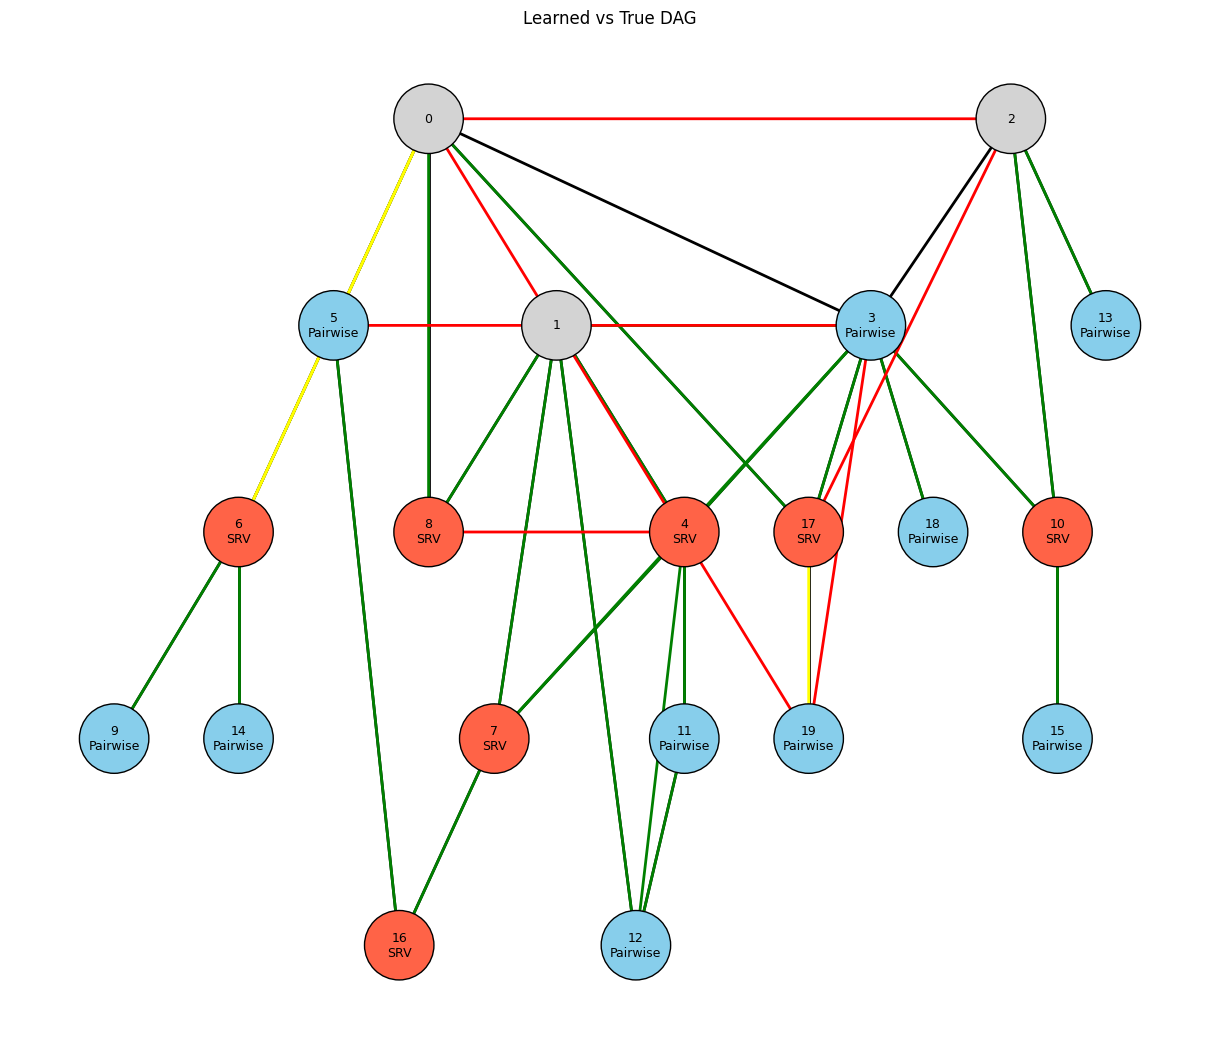

{'correct_directed': {(0, 8),
  (0, 17),
  (1, 8),
  (2, 10),
  (2, 13),
  (3, 10),
  (3, 17),
  (5, 16),
  (7, 16),
  (10, 15)},
 'correct_undirected': {frozenset({3, 4}),
  frozenset({6, 9}),
  frozenset({1, 4}),
  frozenset({1, 7}),
  frozenset({11, 12}),
  frozenset({6, 14}),
  frozenset({1, 12}),
  frozenset({4, 11}),
  frozenset({3, 18}),
  frozenset({4, 7})},
 'wrong_dir': {(5, 0), (6, 0), (6, 5), (19, 17)},
 'extra_directed': {(0, 2), (0, 19), (3, 5), (3, 19), (4, 8), (17, 2)},
 'extra_undirected': {frozenset({4, 12}),
  frozenset({1, 3}),
  frozenset({3, 7})},
 'missing': {(0, 3), (0, 5), (0, 6), (2, 3), (5, 6), (17, 19)},
 'precision': 0.6060606060606061,
 'recall': 0.7692307692307693,
 'f1': 0.6779661016949152}

In [188]:
compare_dags_with_labels(results_sub.true_dags[0], cpdag_nx, results_sub.metadata[0], title="Learned vs True DAG")